In [15]:
from langgraph.graph import StateGraph ,START,END
from typing import TypedDict
import string

In [16]:

class BMIState(TypedDict):   # state defination 
    weight_kg : float
    height_m : float
    bmi : float
    category : string

In [5]:
def calculateBMI(state:BMIState)-> BMIState:
    wt = state['weight_kg']
    ht = state['height_m']
    bmi = round(1.0*wt/(ht*ht),2)
    state['bmi'] = bmi
    return state

In [22]:
def find_category(state:BMIState) -> BMIState : 
    bmi = state['bmi']
    if bmi < 18.5 :
        state['category'] = 'under_weight'
    elif bmi < 24.9 :
        state['category'] = 'healthy_weight'
    elif bmi < 29.9 :
        state['category'] = 'over_weight'
    elif bmi < 34.9 : 
        state['category']  = 'class 1 obesity'
    elif bmi < 39.9 : 
        state['category'] = 'class 2 obesity'
    else :
        state['category'] = 'class 3 obesity'
    return state

In [23]:
#  define graph 
graph = StateGraph(BMIState)
# add nodes 
graph.add_node('BMICalculation',calculateBMI)
graph.add_node('find_category',find_category)
# add edges 
graph.add_edge(START,'BMICalculation')
graph.add_edge('BMICalculation','find_category')
graph.add_edge('find_category',END)

# compile the graph 
workflow = graph.compile()

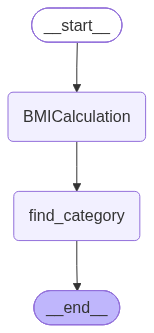

In [24]:
workflow

In [26]:
# execute the graph 
workflow.invoke({'height_m':1.83,'weight_kg':80.0})

{'weight_kg': 80.0,
 'height_m': 1.83,
 'bmi': 23.89,
 'category': 'healthy_weight'}